In [8]:
import re
import math
import zlib
import statistics
from collections import Counter

def extract_top_features(code):
    if not code or not code.strip():
        return None

    lines = code.split('\n')
    
    # Feature 1: std line length / avg line length
    non_empty_lines = [len(line) for line in lines if line.strip()]
    if len(non_empty_lines) > 1:
        avg_line_len = statistics.mean(non_empty_lines)
        std_line_len = statistics.stdev(non_empty_lines)
        cv_line_len = std_line_len / avg_line_len if avg_line_len > 0 else 0
    else:
        cv_line_len = 0.0

    # Find words (keywords + variables + func names + ...)
    words = re.findall(r'\b[a-zA-Z_][a-zA-Z0-9_]*\b', code)

    # Feature 2: avg words length
    if words:
        avg_id_len = sum(len(w) for w in words) / len(words)
    else:
        avg_id_len = 0.0

    # Feature 3: blank line ratio (blank lines / total lines)
    blank_lines = sum(1 for line in lines if not line.strip())
    blank_line_ratio = blank_lines / len(lines) if lines else 0.0

    # Feature 4: compression ratio 
    code_bytes = code.encode('utf-8')
    compressed_bytes = zlib.compress(code_bytes)
    compression_ratio = len(compressed_bytes) / len(code_bytes)

    # Feature 5: words entropy 
    if words:
        word_counts = Counter(words)
        total_words = len(words)
        
        entropy = 0.0
        for count in word_counts.values():
            p = count / total_words
            entropy -= p * math.log2(p)
    else:
        entropy = 0.0

    return {
        "line_length": round(cv_line_len, 4),        # std / avg
        "word_length": round(avg_id_len, 4) / 4,
        "blank_line": round(blank_line_ratio, 4),
        "compression": round(compression_ratio, 4),
        "word_entropy": (round(entropy, 4) - 3) / 2
    }

# --- Test ---
ai_code = """
import math

def is_prime(n):
    if n < 2:
        return False
    if n == 2:
        return True
    if n % 2 == 0:
        return False
    for i in range(3, int(math.isqrt(n)) + 1, 2):
        if n % i == 0:
            return False
    return True

n = int(input())
a = list(map(int, input().split()))

min_prime = -1

for x in a:
    if is_prime(x):
        if min_prime == -1 or x < min_prime:
            min_prime = x

print(min_prime)
"""

human_code = """
(a, b, c, d) = [int(x) for x in input().split()]
k = input()
(p, q, r, s) = (0, 0, 0, 0)
for i in k:
	if i == '1':
		p += 1
	elif i == '2':
		q += 1
	elif i == '3':
		r += 1
	elif i == '4':
		s += 1
print(a * p + b * q + c * r + d * s)
"""

ai_features = extract_top_features(ai_code)
human_features = extract_top_features(human_code)

for k, v in ai_features.items():
    print(f"{k}: {v}")

print("\n--------------\nHuman:")
for k, v in human_features.items():
    print(f"{k}: {v}")

line_length: 0.4907
word_length: 0.931025
blank_line: 0.2593
compression: 0.4586
word_entropy: 0.6368499999999999

--------------
Human:
line_length: 0.723
word_length: 0.452375
blank_line: 0.1333
compression: 0.6287
word_entropy: 0.5606499999999999


# Get code lists

In [1]:
import pandas as pd

df = pd.read_parquet("../data/validation.parquet")

human_codes = df[df["label"] == 0]["code"].tolist()
ai_codes = df[df["label"] == 1]["code"].tolist()

print(len(human_codes), len(ai_codes))

47695 52305


# Mean & std of features

In [9]:
import numpy as np

def features_statistics(codes: list, return_lists=False):
    """ 
    This function returns the statistics of the 5 features, computing accross a list of codes.
    
    Returns:
        [mean, std] of each feature if return_lists = False
        lists of each feature values if return_lists = True
    """
    line_lengths = []
    word_lengths = []
    blank_line_ratios = []
    compression_ratios = []
    word_entropies = []

    for code in codes:
        features = extract_top_features(code)
        line_lengths.append(features["line_length"])
        word_lengths.append(features["word_length"])
        blank_line_ratios.append(features["blank_line"])
        compression_ratios.append(features["compression"])
        word_entropies.append(features["word_entropy"])
    
    if (return_lists):
        return [line_lengths, word_lengths, blank_line_ratios, compression_ratios, word_entropies]
    
    statistics = {
        "line_length": [round(np.mean(line_lengths), 3), round(np.std(line_lengths), 3)],
        "word_length": [round(np.mean(word_lengths), 3), round(np.std(word_lengths), 3)],
        "blank_line": [round(np.mean(blank_line_ratios), 3), round(np.std(blank_line_ratios), 3)],
        "compression": [round(np.mean(compression_ratios), 3), round(np.std(compression_ratios), 3)],
        "word_entropy": [round(np.mean(word_entropies), 3), round(np.std(word_entropies), 3)],
    }

    return statistics

# Test -----
# exp_ai_codes = ai_codes[:]
# exp_human_codes = human_codes[:]

# print("--- Human:")
# human_stt = features_statistics(exp_human_codes)
# for k, v in human_stt.items():
#     print(f"{k}: {v}")

# print("\n--- AI:")
# ai_stt = features_statistics(exp_ai_codes)
# for k, v in ai_stt.items():
#     print(f"{k}: {v}")
    


In [52]:
exp_ai_codes = ai_codes[15000:17000]
exp_human_codes = human_codes[15000:17000]

print("--- Human:")
human_stt = features_statistics(exp_human_codes)
for k, v in human_stt.items():
    print(f"{k}: {v}")

print("\n--- AI:")
ai_stt = features_statistics(exp_ai_codes)
for k, v in ai_stt.items():
    print(f"{k}: {v}")

--- Human:
line_length: [0.283, 0.089]
word_length: [0.394, 0.101]
blank_line: [0.056, 0.056]
compression: [0.293, 0.078]
word_entropy: [0.568, 0.334]

--- AI:
line_length: [0.339, 0.153]
word_length: [0.502, 0.136]
blank_line: [0.076, 0.055]
compression: [0.243, 0.074]
word_entropy: [0.915, 0.505]


# Diagrams

In [19]:
human_feat_lists = features_statistics(human_codes[10000:50000], return_lists=True)
ai_feat_lists = features_statistics(ai_codes[10000:50000], return_lists=True)

### 1D Diagram (1 feature)

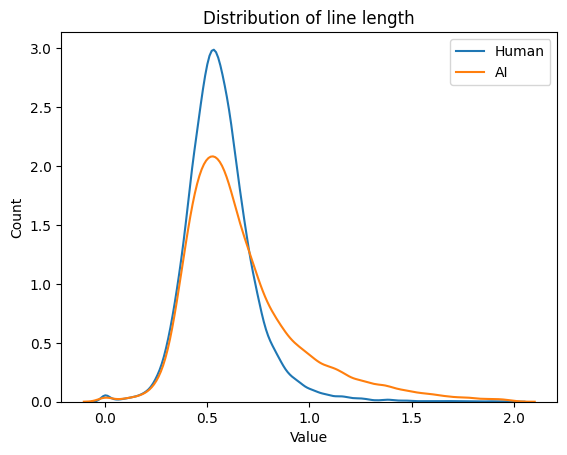

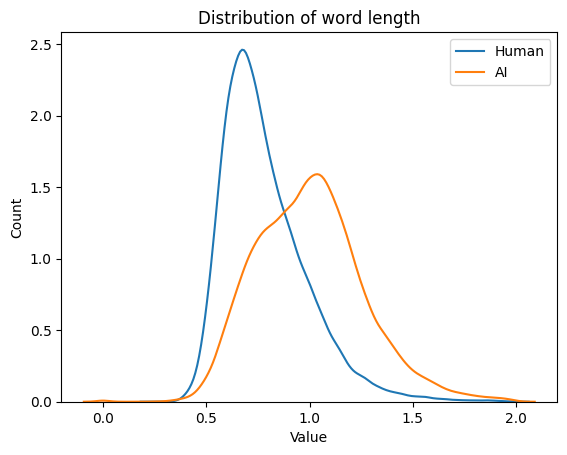

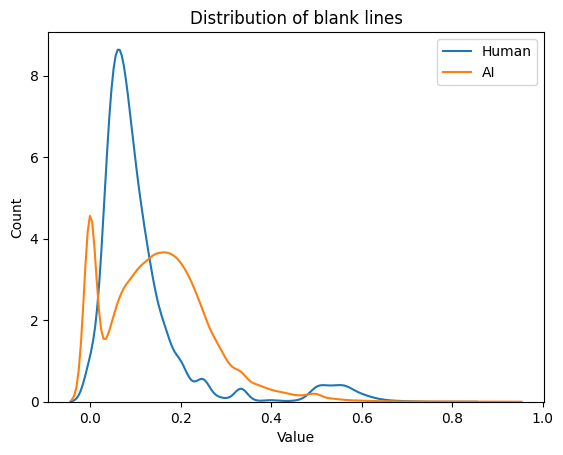

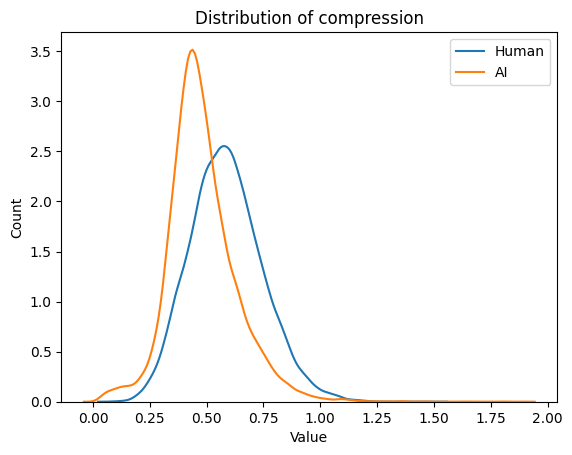

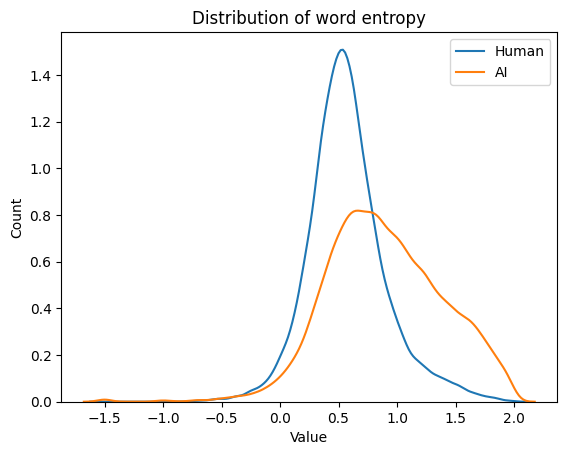

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

feat_names = ["line length", "word length", "blank lines", "compression", "word entropy"]

for feat_idx in range(5):
    human = [x for x in human_feat_lists[feat_idx] if x < 2]
    ai = [x for x in ai_feat_lists[feat_idx] if x < 2]

    plt.figure()

    sns.kdeplot(human, label="Human")
    sns.kdeplot(ai, label="AI")

    plt.xlabel("Value")
    plt.ylabel("Count")
    plt.title("Distribution of " + feat_names[feat_idx])
    plt.legend()
    plt.show()


### 2D diagram (2 features)

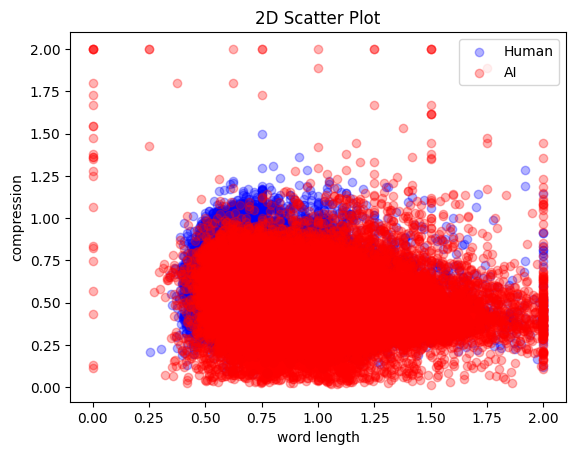

In [22]:
feat_names = ["line length", "word length", "blank lines", "compression", "word entropy"]

idx1, idx2 = 1, 3

human1 = np.clip([x for x in human_feat_lists[idx1]], 0, 2)
human2 = np.clip([x for x in human_feat_lists[idx2]], 0, 2)
ai1 = np.clip([x for x in ai_feat_lists[idx1]], 0, 2)
ai2 = np.clip([x for x in ai_feat_lists[idx2]], 0, 2)

import matplotlib.pyplot as plt

plt.figure()

plt.scatter(human1, human2, color='blue', alpha=0.3, label="Human")
plt.scatter(ai1, ai2, color='red', alpha=0.3, label="AI")

plt.xlabel(feat_names[idx1])
plt.ylabel(feat_names[idx2])
plt.title("2D Scatter Plot")

plt.legend()

plt.show()


### 3D diagram

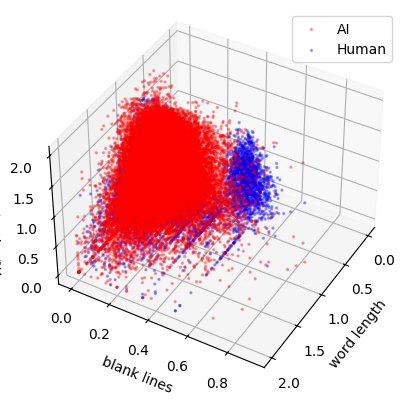

In [23]:
import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

feat_names = ["line length", "word length", "blank lines", "compression", "word entropy"]
idx1, idx2, idx3 = 1, 2, 4

human1 = np.clip([x for x in human_feat_lists[idx1]], 0, 2)
human2 = np.clip([x for x in human_feat_lists[idx2]], 0, 2)
human3 = np.clip([x for x in human_feat_lists[idx3]], 0, 2)
ai1 = np.clip([x for x in ai_feat_lists[idx1]], 0, 2)
ai2 = np.clip([x for x in ai_feat_lists[idx2]], 0, 2)
ai3 = np.clip([x for x in ai_feat_lists[idx3]], 0, 2)

ax.scatter(ai1, ai2, ai3, color='red', alpha=0.3, s = 2, label="AI")
ax.scatter(human1, human2, human3, color='blue', alpha=0.3, s = 2, label="Human")

ax.set_xlabel(feat_names[idx1])
ax.set_ylabel(feat_names[idx2])
ax.set_zlabel(feat_names[idx3])

ax.view_init(elev=40, azim=30)
ax.legend()

plt.show()


In [94]:
# !python -m pip install plotly
!python -m pip install nbformat>=4.2.0

In [32]:
import plotly.express as px
import pandas as pd

# Choose features
feat_names = ["line length", "word length", "blank lines", "compression", "word entropy"]
idx1, idx2, idx3 = 1, 3, 4

human1 = np.clip([x for x in human_feat_lists[idx1][:1000]], 0, 2)
human2 = np.clip([x for x in human_feat_lists[idx2][:1000]], 0, 2)
human3 = np.clip([x for x in human_feat_lists[idx3][:1000]], 0, 2)
ai1 = np.clip([x for x in ai_feat_lists[idx1][:1000]], 0, 2)
ai2 = np.clip([x for x in ai_feat_lists[idx2][:1000]], 0, 2)
ai3 = np.clip([x for x in ai_feat_lists[idx3][:1000]], 0, 2)

feat1, feat2, feat3 = feat_names[idx1], feat_names[idx2], feat_names[idx3] 

df_human = pd.DataFrame({
    feat1: human1,
    feat2: human2,
    feat3: human3,
    "label": ["Human"] * len(human1)
})

df_ai = pd.DataFrame({
    feat1: ai1,
    feat2: ai2,
    feat3: ai3,
    "label": ["AI"] * len(ai1)
})

df = pd.concat([df_human, df_ai], ignore_index=True)

fig = px.scatter_3d(df, x=feat1, y=feat2, z=feat3, color='label')
fig.update_traces(marker=dict(size=2), opacity=0.4)
fig.show()
